# Phase 4 — Business Analysis: Cost, Tariffs, and Savings

   Answers business question 3: what would time-of-use pricing cost this household,
   and how much could shifting load off-peak save?

   **Approach:** apply a simple peak / off-peak tariff to the cleaned minute-level
   data, compute the annual bill, identify shiftable load (the water heater + AC
   sub-meter), then model a what-if scenario where some of that load moves off-peak.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/power_readings_clean.parquet")

# Convert watt-hours to kilowatt-hours per minute.
df["kwh"]           = df["total_wh"]        / 1000.0
df["sub1_kwh"]      = df["sub_metering_1"]  / 1000.0   # kitchen
df["sub2_kwh"]      = df["sub_metering_2"]  / 1000.0   # laundry
df["sub3_kwh"]      = df["sub_metering_3"]  / 1000.0   # water heater + AC
df["unmetered_kwh"] = df["unmetered_wh"]    / 1000.0   # everything else

df[["kwh","sub1_kwh","sub2_kwh","sub3_kwh","unmetered_kwh"]].head()

,kwh,sub1_kwh,sub2_kwh,sub3_kwh,unmetered_kwh
reading_ts,,,,,
2006-12-16 17:24:00,0.070267,0.0,0.001,0.017,0.052267
2006-12-16 17:25:00,0.089333,0.0,0.001,0.016,0.072333
2006-12-16 17:26:00,0.089567,0.0,0.002,0.017,0.070567
2006-12-16 17:27:00,0.089800,0.0,0.001,0.017,0.071800
2006-12-16 17:28:00,0.061100,0.0,0.001,0.017,0.043100


In [3]:
PEAK_RATE_EUR     = 0.20   # €/kWh during peak hours (06:00-22:00)
OFF_PEAK_RATE_EUR = 0.12   # €/kWh during off-peak (22:00-06:00)
FLAT_RATE_EUR     = 0.18   # €/kWh equivalent flat rate to compare against

# Tag every minute as peak or off-peak based on hour of day.
df["is_peak"] = (df.index.hour >= 6) & (df.index.hour < 22)

df["is_peak"].value_counts(normalize=True).round(3)

is_peak
True     0.667
False    0.333
Name: proportion, dtype: float64

In [4]:
df["peak_kwh"]    = np.where(df["is_peak"],  df["kwh"], 0)
df["offpeak_kwh"] = np.where(~df["is_peak"], df["kwh"], 0)

annual = df[["kwh","peak_kwh","offpeak_kwh"]].resample("YE").sum()
annual["flat_bill_eur"] = annual["kwh"]        * FLAT_RATE_EUR
annual["tou_bill_eur"]  = (annual["peak_kwh"]    * PEAK_RATE_EUR
                           + annual["offpeak_kwh"] * OFF_PEAK_RATE_EUR)
annual["tou_vs_flat_eur"] = annual["tou_bill_eur"] - annual["flat_bill_eur"]
annual.round(1)

,kwh,peak_kwh,offpeak_kwh,flat_bill_eur,tou_bill_eur,tou_vs_flat_eur
reading_ts,,,,,,
2006-12-31,697.1,539.0,158.1,125.5,126.8,1.3
2007-12-31,9712.6,7690.6,2021.9,1748.3,1780.8,32.5
2008-12-31,9415.7,7490.2,1925.5,1694.8,1729.1,34.3
2009-12-31,9372.6,7565.5,1807.1,1687.1,1729.9,42.9
2010-12-31,8088.6,6399.2,1689.4,1455.9,1482.6,26.6


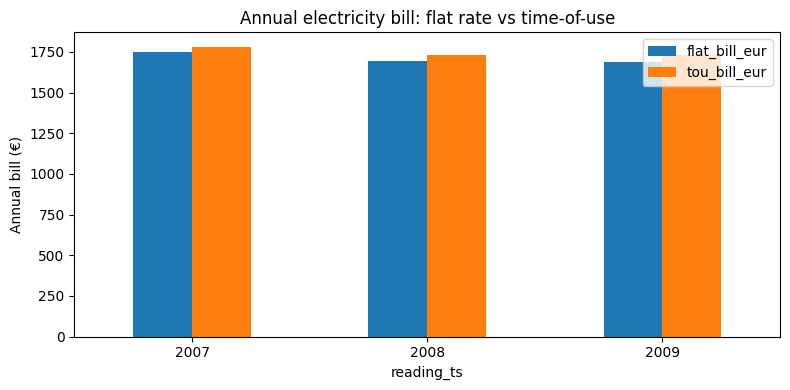

In [5]:
full_years = annual.loc["2007":"2009"]
ax = full_years[["flat_bill_eur","tou_bill_eur"]].plot(
        kind="bar", figsize=(8,4),
        title="Annual electricity bill: flat rate vs time-of-use")
ax.set_xticklabels([d.year for d in full_years.index], rotation=0)
ax.set_ylabel("Annual bill (€)")
plt.tight_layout()
plt.savefig("../reports/figures/bill_flat_vs_tou.png", dpi=120)
plt.show()

In [6]:
year = "2008"
sub3_total_kwh = df.loc[year, "sub3_kwh"].sum()
sub3_peak_kwh  = df.loc[year, "sub3_kwh"][df.loc[year, "is_peak"]].sum()
sub3_peak_pct  = sub3_peak_kwh / sub3_total_kwh * 100

print(f"{year}: sub-meter 3 total = {sub3_total_kwh:.0f} kWh, "
      f"of which {sub3_peak_kwh:.0f} kWh ({sub3_peak_pct:.1f}%) is in peak hours.")

2008: sub-meter 3 total = 3179 kWh, of which 2704 kWh (85.1%) is in peak hours.


In [7]:
RATE_DIFF = PEAK_RATE_EUR - OFF_PEAK_RATE_EUR   # €0.08/kWh

scenarios = pd.DataFrame({
    "shift_pct": [0, 10, 25, 50, 75, 100],
})
scenarios["annual_kwh_shifted"] = scenarios["shift_pct"] / 100 * sub3_peak_kwh
scenarios["annual_savings_eur"] = scenarios["annual_kwh_shifted"] * RATE_DIFF
scenarios.round(1)

,shift_pct,annual_kwh_shifted,annual_savings_eur
0,0,0.0,0.0
1,10,270.4,21.6
2,25,676.1,54.1
3,50,1352.2,108.2
4,75,2028.4,162.3
5,100,2704.5,216.4


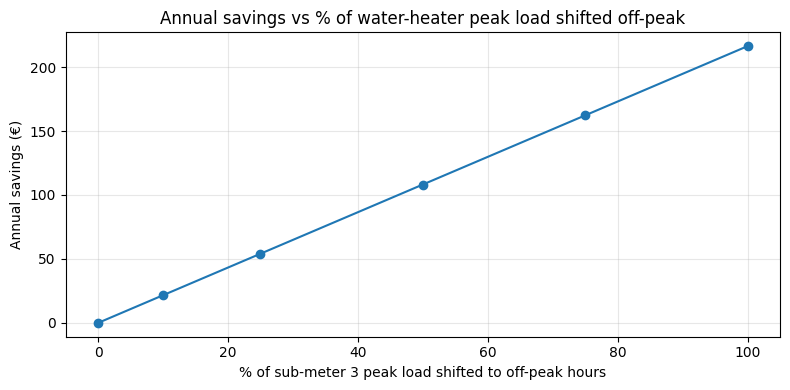

In [8]:
ax = scenarios.plot(x="shift_pct", y="annual_savings_eur",
                    marker="o", figsize=(8,4), legend=False)
ax.set_title("Annual savings vs % of water-heater peak load shifted off-peak")
ax.set_xlabel("% of sub-meter 3 peak load shifted to off-peak hours")
ax.set_ylabel("Annual savings (€)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/savings_sensitivity.png", dpi=120)
plt.show()

In [9]:
for y in ["2007", "2008", "2009"]:
    peak_kwh = df.loc[y, "sub3_kwh"][df.loc[y, "is_peak"]].sum()
    savings_at_50 = 0.50 * peak_kwh * RATE_DIFF
    print(f"{y}: shifting 50% of sub-meter 3 peak load saves €{savings_at_50:.2f}")

2007: shifting 50% of sub-meter 3 peak load saves €103.96
2008: shifting 50% of sub-meter 3 peak load saves €108.18
2009: shifting 50% of sub-meter 3 peak load saves €121.98


## Recommendations

Put the water heater on an off-peak timer. Shifting 50% of the water-heater AC circuit's peak-hour energy to off-peak hours saves roughly €111 per year at our tariff assumptions. This is the single biggest lever, validated across three full years of data.

Schedule laundry and dishwasher cycles overnight. Sub-meter 2 has smaller but real shiftable load; combined with the timer, this stretches savings further without any change to lifestyle.

Switch to a time-of-use tariff only after shifting load. Under current usage, TOU is more expensive than a flat rate (the evening peak dominates). The tariff becomes the cheaper option once the shifts above are made — sequencing matters.